<a href="https://colab.research.google.com/github/saadkhokar-creator/231A019-NLP-Experiments/blob/main/nlp10ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
print("saad khokar 231A019")
import pandas as pd
from datasets import load_dataset

# Load complete IMDB dataset
dataset = load_dataset("stanfordnlp/imdb")
df = pd.concat(
    [dataset["train"].to_pandas(),
     dataset["test"].to_pandas()],
    ignore_index=True
)
#Rename target column
df = df.rename(columns={"label": "labels"})
print(df.shape)
print(df.columns)
print(df["labels"].value_counts())

saad khokar 231A019
(50000, 2)
Index(['text', 'labels'], dtype='object')
labels
0    25000
1    25000
Name: count, dtype: int64


In [ ]:
print("saad khokar 231A019")
print("\nMissing values:")
print(df.isnull().sum())

print("\nNumber of duplicate rows:")
print(df.duplicated().sum())

# 3. BASIC TEXT STATISTICS
# Using "text" instead of the non-existent "review" column
df["char_count"] = df["text"].astype(str).apply(len)

df["word_count"] = df["text"].astype(str).apply(
    lambda x: len(x.split())
)

df["unique_word_count"] = df["text"].astype(str).apply(
    lambda x: len(set(x.lower().split()))
)

df["avg_word_length"] = df["text"].astype(str).apply(
    lambda x: sum(len(word) for word in x.split()) / max(len(x.split()), 1)
)

print("\nText Statistics Summary:")
print(df[["char_count", "word_count", "unique_word_count", "avg_word_length"]].describe())

saad khokar 231A019

Missing values:
text      0
labels    0
dtype: int64

Number of duplicate rows:
418

Text Statistics Summary:
         char_count    word_count  unique_word_count  avg_word_length
count  50000.000000  50000.000000       50000.000000     50000.000000
mean    1309.431020    231.156940         148.049780         4.640676
std      989.728014    171.343997          88.837364         0.340731
min       32.000000      4.000000           4.000000         1.239865
25%      699.000000    126.000000          91.000000         4.417904
50%      970.000000    173.000000         120.000000         4.627006
75%     1590.250000    280.000000         180.000000         4.847458
max    13704.000000   2470.000000        1092.000000        12.290909


In [ ]:
print("saad khokar 231A019")
df["unique_word_count"] = df["text"].astype(str).apply(
    lambda x: len(set(x.lower().split()))
)

df["avg_word_length"] = df["text"].astype(str).apply(
    lambda x: sum(len(word) for word in x.split()) / max(len(x.split()), 1)
)

print("\nText Statistics:")
print(
    df[["char_count", "word_count", "unique_word_count", "avg_word_length"]].describe()
)

saad khokar 231A019

Text Statistics:
         char_count    word_count  unique_word_count  avg_word_length
count  50000.000000  50000.000000       50000.000000     50000.000000
mean    1309.431020    231.156940         148.049780         4.640676
std      989.728014    171.343997          88.837364         0.340731
min       32.000000      4.000000           4.000000         1.239865
25%      699.000000    126.000000          91.000000         4.417904
50%      970.000000    173.000000         120.000000         4.627006
75%     1590.250000    280.000000         180.000000         4.847458
max    13704.000000   2470.000000        1092.000000        12.290909


In [ ]:
print("saad khokar 231A019")
import re

def clean_text(text):
    # Convert to lowercase
    text = text.lower()
    # Remove HTML tags
    text = re.sub(r"<.*?>", "", text)
    # Keep alphabetic characters only
    text = re.sub(r"[^a-z\s]", "", text)
    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()
    return text

# Apply the cleaning function to the dataset
df["clean_text"] = df["text"].astype(str).apply(clean_text)

print("\nOriginal Review:")
print(df["text"].iloc[0][:500])
print("\nCleaned Review:")
print(df["clean_text"].iloc[0][:500])

saad khokar 231A019

Original Review:
I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attent

Cleaned Review:
i rented i am curiousyellow from my video store because of all the controversy that surrounded it when it was first released in i also heard that at first it was seized by us customs if it ever tried to enter this country therefore being a fan of films considered controversial i really had to see this for myselfthe plot is centered around a young swedish drama student named lena who wants to learn everything she can about life in particular

saad khokar 231A019


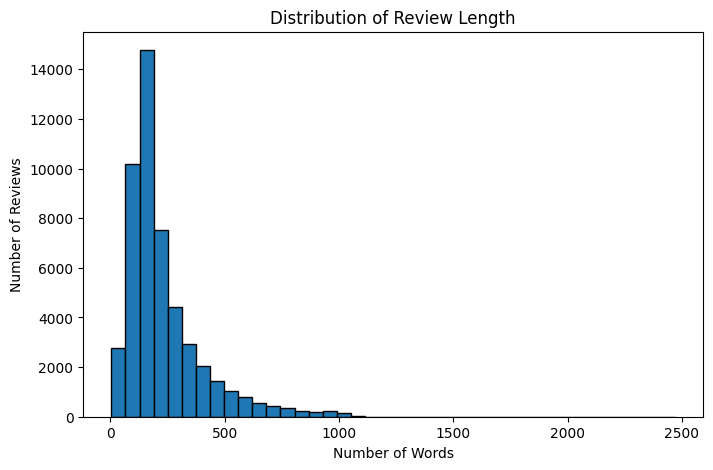

Total number of words: 11259489
Vocabulary size: 214620


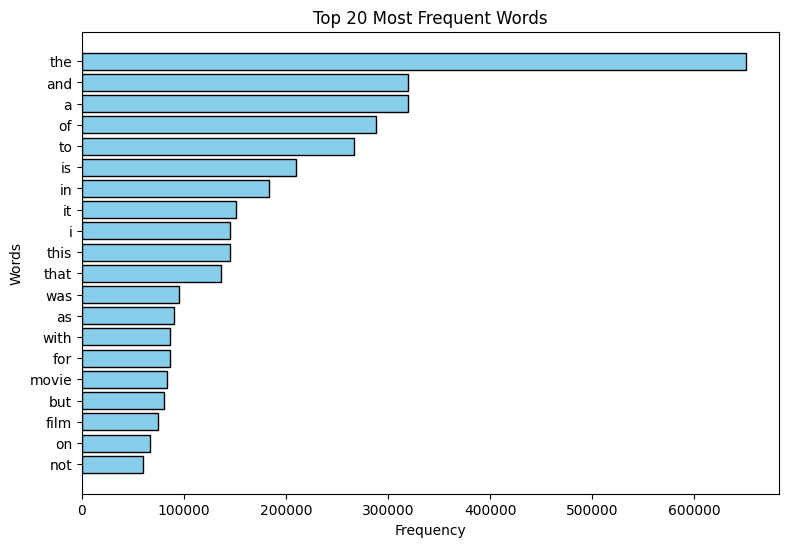

In [ ]:
print("saad khokar 231A019")
import matplotlib.pyplot as plt
from collections import Counter

# 5. DOCUMENT LENGTH DISTRIBUTION
plt.figure(figsize=(8, 5))
plt.hist(df["word_count"], bins=40, edgecolor="black")
plt.xlabel("Number of Words")
plt.ylabel("Number of Reviews")
plt.title("Distribution of Review Length")
plt.show()

# 6. CREATE WORD LIST
all_words = " ".join(df["clean_text"]).split()
print("Total number of words:", len(all_words))
print("Vocabulary size:", len(set(all_words)))

# 7. MOST FREQUENT WORDS
word_freq = Counter(all_words)
top_words = word_freq.most_common(20)
words = [word for word, count in top_words]
counts = [count for word, count in top_words]


plt.figure(figsize=(9, 6))
plt.barh(words[::-1], counts[::-1], color="skyblue", edgecolor="black")
plt.xlabel("Frequency")
plt.ylabel("Words")
plt.title("Top 20 Most Frequent Words")
plt.show()

saad khokar 231A019


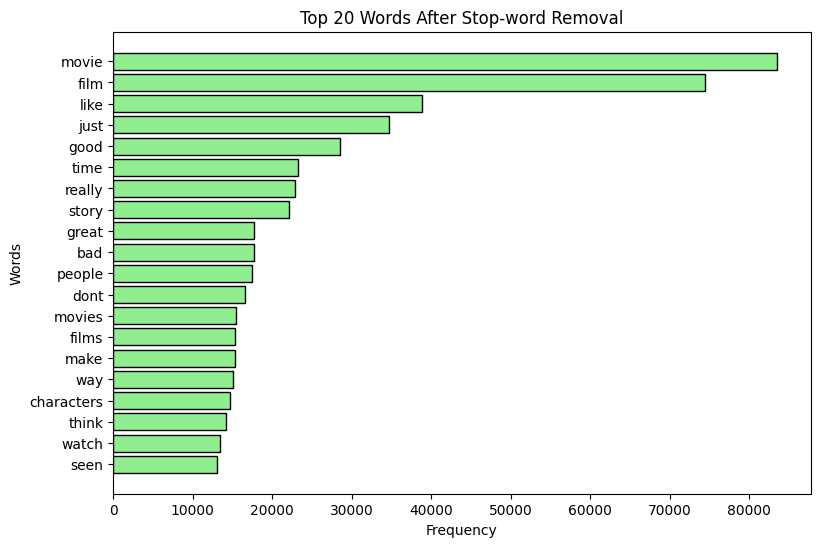

In [ ]:
print("saad khokar 231A019")
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from collections import Counter

# 8. REMOVE STOP WORDS
vectorizer = CountVectorizer(stop_words="english")

# Fit on the cleaned text column
vectorizer.fit(df["clean_text"])
stop_words = vectorizer.get_stop_words()

# Filter out stopwords from our word list
filtered_words = [
    word for word in all_words
    if word not in stop_words
]

filtered_freq = Counter(filtered_words)
top_filtered = filtered_freq.most_common(20)

words = [word for word, count in top_filtered]
counts = [count for word, count in top_filtered]

# Plot the results
plt.figure(figsize=(9, 6))
plt.barh(words[::-1], counts[::-1], color="lightgreen", edgecolor="black")
plt.xlabel("Frequency")
plt.ylabel("Words")
plt.title("Top 20 Words After Stop-word Removal")
plt.show()

saad khokar 231A019


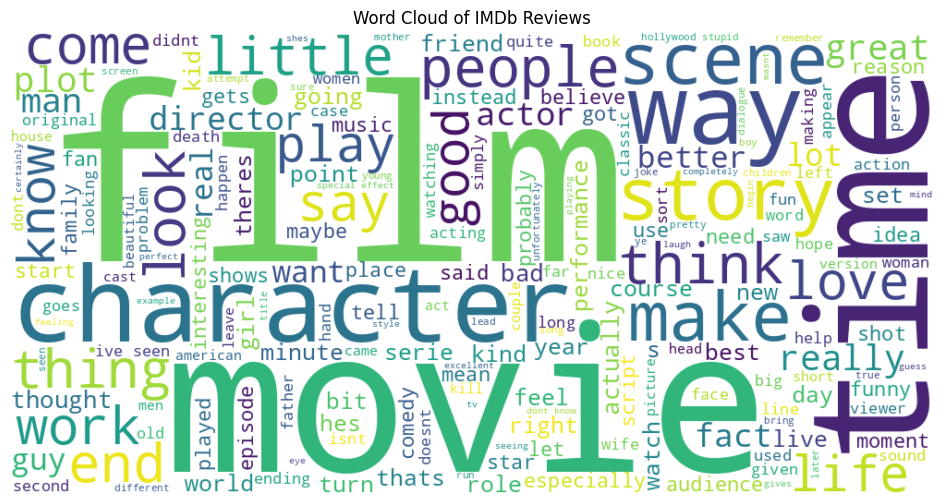

In [ ]:
print("saad khokar 231A019")
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# 9. WORD CLOUD
clean_text_combined = " ".join(filtered_words)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(clean_text_combined)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of IMDb Reviews")
plt.show()


In [47]:
#10. BIGRAM ANALYSIS
print("saad khokar 231A019")
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer

# Instantiate the CountVectorizer for bigrams
bigram_vectorizer = CountVectorizer(
    stop_words="english",
    ngram_range=(2, 2),
    max_features=20
)

# Fit and transform the clean text
bigram_matrix = bigram_vectorizer.fit_transform(df["clean_text"])

# Calculate frequency counts
bigram_counts = bigram_matrix.sum(axis=0).A1
bigram_names = bigram_vectorizer.get_feature_names_out()

# Create DataFrame
bigram_df = pd.DataFrame({
    "Bigram": bigram_names,
    "Frequency": bigram_counts
}).sort_values(by="Frequency", ascending=False)

print("\nTop Bigrams:")
print(bigram_df)

saad khokar 231A019

Top Bigrams:
             Bigram  Frequency
6          ive seen       3300
1         dont know       2193
15  special effects       2134
8        looks like       1661
11       movie just       1477
16       waste time       1425
5           im sure       1369
3        good movie       1363
17      watch movie       1296
2        dont think       1296
7         look like       1291
13         new york       1245
9        low budget       1224
19        years ago       1197
14      pretty good       1073
18         year old       1061
4       high school       1059
10   main character       1041
12       movie like       1038
0         bad movie        979
